In [1]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 74.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


# Banana Classification using EfficientNet

In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import glob
from collections import Counter
import random
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import classification_report, confusion_matrix

from roboflow import Roboflow
# from kaggle_secrets import UserSecretsClient

from google.colab.patches import cv2_imshow
from google.colab import userdata

## Problem Definition
- Task type: Classification
- Objective: Classify banana images into: freshripe, freshunripe, overripe, ripe, rotten, unripe
- Type: multiclass Classification

## Dataset + EDA

In [6]:
# user_secrets = UserSecretsClient()
# rf = Roboflow(api_key=user_secrets.get_secret("ROBOFLOW_API_KEY"))
rf = Roboflow(api_key=userdata.get("ROBOFLOW_API_KEY"))
project = rf.workspace("chetan-sharma-n4cau").project("banana-ripeness-classification-a9hps")
version = project.version(3)
dataset = version.download("folder")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Banana-Ripeness-Classification-3 in folder:: 100%|██████████| 5639/5639 [00:00<00:00, 12050.44it/s]


In [9]:
data_path = '/content/Banana-Ripeness-Classification-3'
# data_path = '/kaggle/working/Banana-Ripeness-Classification-3'
train_path = os.path.join(data_path, 'train')
valid_path = os.path.join(data_path, 'valid')
test_path = os.path.join(data_path, 'test')
train_labels = os.path.join(train_path, 'labels')

image_dir, label_dir = f"{train_path}/images", f"{train_path}/labels"

In [10]:
def get_class_distribution(path):
    counter = Counter()

    train_path = os.path.join(path, "train")

    for cls in os.listdir(train_path):
        cls_path = os.path.join(train_path, cls)
        counter[cls] = len(os.listdir(cls_path))

    return counter

dist = get_class_distribution(data_path)
print(dist)

Counter({'rotten': 1340, 'overripe': 783, 'freshripe': 704, 'freshunripe': 501, 'ripe': 470, 'unripe': 133})


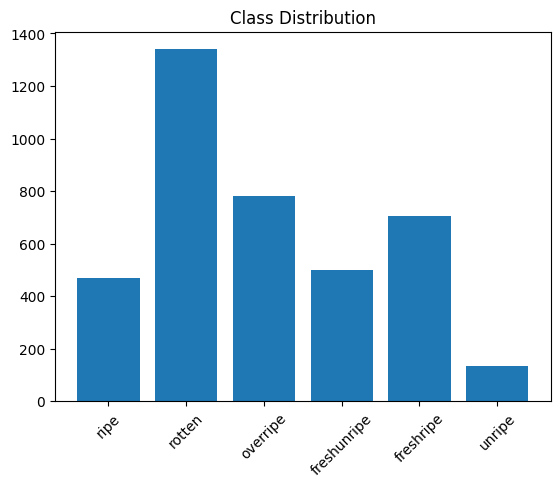

In [11]:
plt.bar(dist.keys(), dist.values())
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

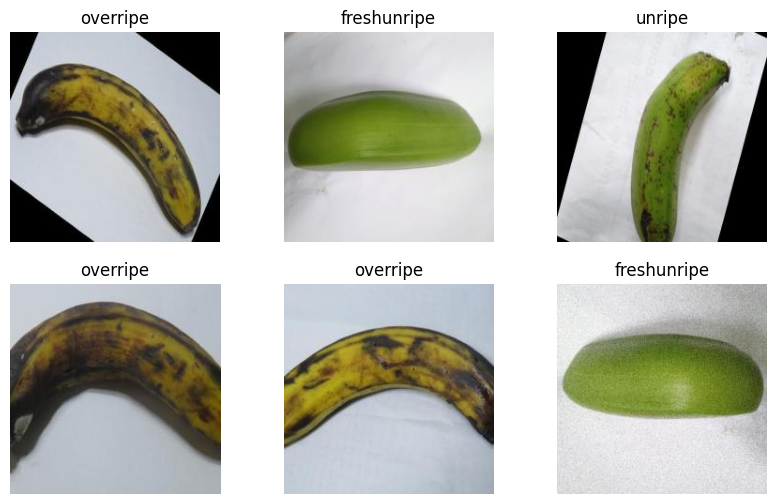

In [12]:
def show_samples(path, n=6):
    train_path = os.path.join(path, "train")

    classes = os.listdir(train_path)

    plt.figure(figsize=(10,6))

    for i in range(n):
        cls = random.choice(classes)
        img_name = random.choice(os.listdir(os.path.join(train_path, cls)))
        img_path = os.path.join(train_path, cls, img_name)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

    plt.show()

show_samples(data_path)

### EDA Findings
- **Dataset Split:**
  - Training set: 7057 images and 7057 labels.
  - Validation set: 2048 images and 2048 labels.
  - Test set: 1020 images and 1020 labels.
- **Class Distribution:** The dataset contains a single class (class `0`) with 7357 instances across the training set, therefore it's a single-object detection task (i.e., license plates).
- **Bounding Box Dimensions:**
  - Average normalized width of bounding boxes: ~0.20
  - Average normalized height of bounding boxes: ~0.15
- **Data Integrity:**
  - No missing label files were found for the images.
  - 5 empty label files were identified, meaning 5 images in the training set do not have any annotations.

## Preprocessing + Augmentation
- auto scaling done in robo flow
- images are resized to 640*640 in roboflow

### Load dataset

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}



image_datasets = {
    'train': datasets.ImageFolder(train_path, data_transforms['train']),
    'val': datasets.ImageFolder(valid_path, data_transforms['val'])
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=32, shuffle=True, num_workers=4),
    'val': DataLoader(image_datasets['val'], batch_size=32, shuffle=False, num_workers=4)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(f"Classes: {class_names}")

Classes: ['freshripe', 'freshunripe', 'overripe', 'ripe', 'rotten', 'unripe']


This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.


## Model + Config

### Why EfficientNet-B0?
- **High Accuracy:** Better performance than ResNet/VGG with fewer parameters.
- **Compound Scaling:** Uniformly scales depth, width, and resolution for better efficiency.
- **Lightweight:** Ideal for mobile and edge deployment due to small model size.
- **Fast Convergence:** Pre-trained ImageNet weights allow for rapid training on custom data.

In [14]:
model_ft = models.efficientnet_b0(weights='IMAGENET1K_V1')

# Adjust the final classifier layer for our 6 classes
num_ftrs = model_ft.classifier[1].in_features
model_ft.classifier[1] = nn.Linear(num_ftrs, len(class_names))

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.Adam(model_ft.parameters(), lr=0.001)
exp_lr_scheduler = optim.lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 155MB/s]


## Training

In [23]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    for epoch in range(num_epochs):
        print('-'*30)
        print(epoch + 1, '/', num_epochs)
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            loop = tqdm(dataloaders[phase], desc=f"{phase.upper()}", leave=False)

            for inputs, labels in loop:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                loop.set_postfix({
                    "loss": loss.item(),
                    "acc": (running_corrects.double() / ((loop.n + 1) * inputs.size(0))).item()
                })

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

    return model

In [24]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=10)

------------------------------
1 / 10


TRAIN:   0%|          | 0/123 [00:00<?, ?it/s]This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.


train Loss: 0.0776 Acc: 0.9763


val Loss: 0.0861 Acc: 0.9768
------------------------------
2 / 10


train Loss: 0.0433 Acc: 0.9852


...

val Loss: 0.0558 Acc: 0.9795
------------------------------
9 / 10


train Loss: 0.0130 Acc: 0.9954


val Loss: 0.0538 Acc: 0.9804
------------------------------
10 / 10


train Loss: 0.0158 Acc: 0.9954


val Loss: 0.0563 Acc: 0.9822


## Evaluation and visualization

In [25]:
def evaluate_model(model, dataloader):
    model.eval()

    running_loss = 0.0
    running_corrects = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects.double() / len(dataloader.dataset)

    print(f"Loss: {epoch_loss:.4f}")
    print(f"Accuracy: {epoch_acc:.4f}")

    return all_preds, all_labels

In [26]:
def show_metrics(all_preds, all_labels, class_names):
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8,6))
    plt.imshow(cm, cmap='Blues')
    plt.title("Confusion Matrix")
    plt.colorbar()

    plt.xticks(range(len(class_names)), class_names, rotation=45)
    plt.yticks(range(len(class_names)), class_names)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(j, i, cm[i, j], ha='center', va='center')

    plt.show()

Evaluating: 100%|██████████| 36/36 [00:02<00:00, 12.55it/s]


Loss: 0.0563
Accuracy: 0.9822

Classification Report:
              precision    recall  f1-score   support

   freshripe       0.99      0.99      0.99       207
 freshunripe       1.00      1.00      1.00       136
    overripe       0.99      0.98      0.98       229
        ripe       0.98      0.97      0.98       132
      rotten       0.98      0.97      0.98       388
      unripe       0.82      1.00      0.90        31

    accuracy                           0.98      1123
   macro avg       0.96      0.99      0.97      1123
weighted avg       0.98      0.98      0.98      1123



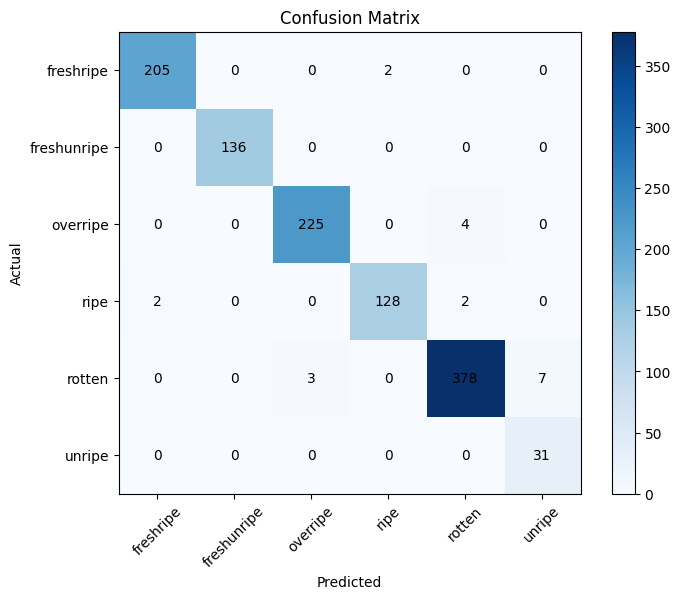

In [29]:
val_preds, val_labels = evaluate_model(model_ft, dataloaders['val'])
show_metrics(val_preds, val_labels, class_names)

## Model TestingPrediction

Evaluating: 100%|██████████| 18/18 [00:01<00:00, 11.55it/s]


Loss: 0.0395
Accuracy: 0.9893

Classification Report:
              precision    recall  f1-score   support

   freshripe       0.99      1.00      1.00       102
 freshunripe       1.00      1.00      1.00        83
    overripe       1.00      0.99      1.00       113
        ripe       1.00      0.98      0.99        52
      rotten       0.99      0.98      0.99       185
      unripe       0.87      1.00      0.93        27

    accuracy                           0.99       562
   macro avg       0.98      0.99      0.98       562
weighted avg       0.99      0.99      0.99       562



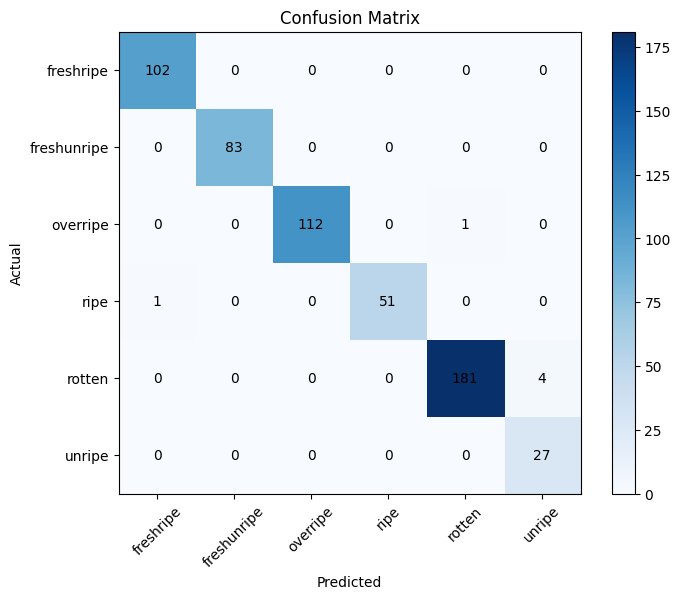

In [30]:
test_dataset = datasets.ImageFolder(test_path, data_transforms['val'])
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

test_preds, test_labels = evaluate_model(model_ft, test_loader)
show_metrics(test_preds, test_labels, class_names)

In [31]:
def visualize_predictions(model, dataloader, class_names, num_images=6):
    model.eval()
    images_so_far = 0

    plt.figure(figsize=(10,10))

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for i in range(inputs.size(0)):
                images_so_far += 1
                ax = plt.subplot(3, 3, images_so_far)
                ax.axis('off')

                img = inputs[i].cpu().numpy().transpose((1,2,0))
                img = np.clip(img, 0, 1)

                ax.imshow(img)
                ax.set_title(f"P: {class_names[preds[i]]}\nT: {class_names[labels[i]]}")

                if images_so_far == num_images:
                    plt.show()
                    return

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.


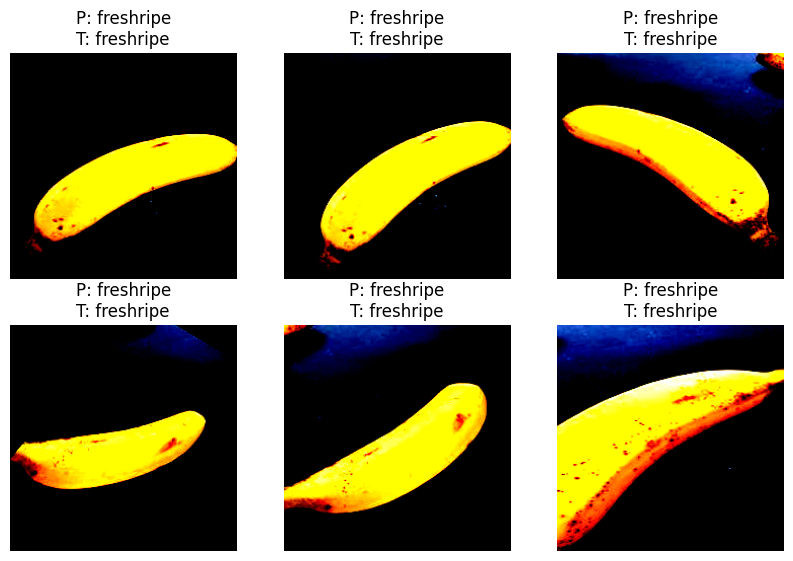

In [32]:
visualize_predictions(model_ft, dataloaders['val'], class_names)

## Inference on unseen data

In [33]:
torch.save(model_ft.state_dict(), "efficientnet_banana.pth")

In [36]:
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

import torch
import torch.nn as nn
from torchvision import models

### Load model

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# recreate model
model = models.efficientnet_b0(weights=None)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, 6)  # same number of classes

# load weights
model.load_state_dict(torch.load("efficientnet_banana.pth", map_location=device))
model = model.to(device)
model.eval()

class_names = ['freshripe','freshunripe','overripe','ripe','rotten','unripe']

### inferance

In [41]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def predict(img_path):
    img = Image.open(img_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(x)
        probs = torch.softmax(out, dim=1)
        conf, pred = torch.max(probs, 1)

    plt.imshow(img)
    plt.title(f"{class_names[pred.item()]} ({conf.item():.2f})")
    plt.axis("off")
    plt.show()

    return class_names[pred.item()], conf.item()

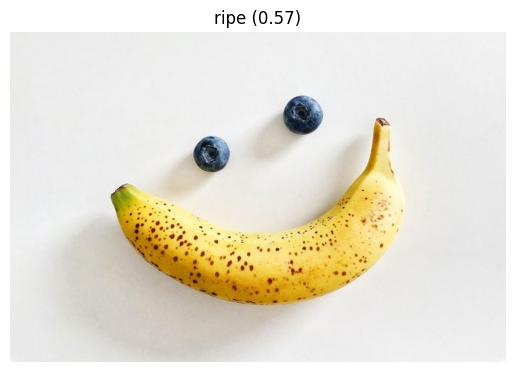

('ripe', 0.5695595741271973)

In [42]:
predict("/content/GettyImages-1046941212-MLedit.jpg")

## Conclusion

### Conclusion

* **Model Performance**: The EfficientNet-B0 model achieved high accuracy on both validation and test sets (~98-99%).
* **Class Sensitivity**: The model shows excellent precision and recall across most classes, including 'freshripe', 'freshunripe', and 'rotten'.
* **Efficient Architecture**: EfficientNet-B0 provides a lightweight yet powerful alternative to larger models, making it suitable for real-time inference.
* **Generalization**: High performance on the unseen test set indicates that the data augmentations and transfer learning approach were effective for this classification task.
* **Inference**: The saved model weights (`efficientnet_banana.pth`) can be easily reloaded for predicting banana ripeness in production environments.